In [3]:
import requests 
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
url="https://pokeapi.co/api/v2/pokemon/1"
response=requests.get(url)
data=response.json()
print(data)

{'abilities': [{'ability': {'name': 'overgrow', 'url': 'https://pokeapi.co/api/v2/ability/65/'}, 'is_hidden': False, 'slot': 1}, {'ability': {'name': 'chlorophyll', 'url': 'https://pokeapi.co/api/v2/ability/34/'}, 'is_hidden': True, 'slot': 3}], 'base_experience': 64, 'cries': {'latest': 'https://raw.githubusercontent.com/PokeAPI/cries/main/cries/pokemon/latest/1.ogg', 'legacy': 'https://raw.githubusercontent.com/PokeAPI/cries/main/cries/pokemon/legacy/1.ogg'}, 'forms': [{'name': 'bulbasaur', 'url': 'https://pokeapi.co/api/v2/pokemon-form/1/'}], 'game_indices': [{'game_index': 153, 'version': {'name': 'red', 'url': 'https://pokeapi.co/api/v2/version/1/'}}, {'game_index': 153, 'version': {'name': 'blue', 'url': 'https://pokeapi.co/api/v2/version/2/'}}, {'game_index': 153, 'version': {'name': 'yellow', 'url': 'https://pokeapi.co/api/v2/version/3/'}}, {'game_index': 1, 'version': {'name': 'gold', 'url': 'https://pokeapi.co/api/v2/version/4/'}}, {'game_index': 1, 'version': {'name': 'silve

DATA EXTRACTION DONE USING API AND NOW AFTER THAT WE WILL PERFORM EDA AND VISUALISATION 


In [5]:
pok_data=[]
for i in range(1,201):
    url=f"https://pokeapi.co/api/v2/pokemon/{i}"
    response=requests.get(url)
    data=response.json()
    stats={}
    for i in data['stats']:
        stats[i['stat']['name']]=i['base_stat']
    pok_data.append({
            'name': data['name'],
            'height': data['height'],
            'weight': data['weight'],
            'base_experience': data['base_experience'],
            'hp': stats.get('hp'),
            'attack': stats.get('attack'),
            'defense': stats.get('defense'),
            'special_attack': stats.get('special-attack'),
            'special_defense': stats.get('special-defense'),
            'speed': stats.get('speed'),
            'primary_type': data['types'][0]['type']['name']})
df=pd.DataFrame(pok_data)
print(df.head())

         name  height  weight  base_experience  hp  attack  defense  \
0   bulbasaur       7      69               64  45      49       49   
1     ivysaur      10     130              142  60      62       63   
2    venusaur      20    1000              236  80      82       83   
3  charmander       6      85               62  39      52       43   
4  charmeleon      11     190              142  58      64       58   

   special_attack  special_defense  speed primary_type  
0              65               65     45        grass  
1              80               80     60        grass  
2             100              100     80        grass  
3              60               50     65         fire  
4              80               65     80         fire  


In [7]:
df=pd.DataFrame(pok_data)
df.to_csv('data/raw_pokemon_data.csv', index=False)

In [8]:
df=pd.read_csv('data/raw_pokemon_data.csv')


In [9]:
df.head()

,name,height,weight,base_experience,hp,attack,defense,special_attack,special_defense,speed,primary_type
0,bulbasaur,7,69,64,45,49,49,65,65,45,grass
1,ivysaur,10,130,142,60,62,63,80,80,60,grass
2,venusaur,20,1000,236,80,82,83,100,100,80,grass
3,charmander,6,85,62,39,52,43,60,50,65,fire
4,charmeleon,11,190,142,58,64,58,80,65,80,fire


In [10]:
df.isnull().sum()

name               0
height             0
weight             0
base_experience    0
hp                 0
attack             0
defense            0
special_attack     0
special_defense    0
speed              0
primary_type       0
dtype: int64

In [11]:
df.describe()

,height,weight,base_experience,hp,attack,defense,special_attack,special_defense,speed
count,200.000000,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000
mean,11.290000,404.92000,132.045000,64.580000,69.38000,66.295000,66.265000,66.745000,66.715000
std,8.808168,540.67336,67.469353,27.038658,26.32834,26.298212,27.809741,24.231297,27.456567
min,2.000000,1.00000,36.000000,10.000000,5.00000,5.000000,15.000000,20.000000,15.000000
25%,6.000000,85.00000,64.000000,45.000000,50.00000,48.750000,45.000000,50.000000,45.000000
50%,10.000000,257.50000,142.000000,60.000000,65.00000,65.000000,60.500000,65.000000,65.000000
75%,14.000000,546.25000,175.000000,80.000000,86.25000,80.000000,85.000000,83.500000,87.750000
max,88.000000,4600.00000,395.000000,250.000000,134.00000,180.000000,154.000000,130.000000,150.000000


In [12]:
df.dtypes

name               object
height              int64
weight              int64
base_experience     int64
hp                  int64
attack              int64
defense             int64
special_attack      int64
special_defense     int64
speed               int64
primary_type       object
dtype: object

In [13]:
df['total_power']=df['hp']+df['attack']+df['defense']+df['special_attack']+df['special_defense']+df['speed']

In [14]:
df

,name,height,weight,base_experience,hp,attack,defense,special_attack,special_defense,speed,primary_type,total_power
0,bulbasaur,7,69,64,45,49,49,65,65,45,grass,318
1,ivysaur,10,130,142,60,62,63,80,80,60,grass,405
2,venusaur,20,1000,236,80,82,83,100,100,80,grass,525
3,charmander,6,85,62,39,52,43,60,50,65,fire,309
4,charmeleon,11,190,142,58,64,58,80,65,80,fire,405
...,...,...,...,...,...,...,...,...,...,...,...,...
195,espeon,9,265,184,65,65,60,130,95,110,psychic,525
196,umbreon,10,270,184,95,65,110,60,130,65,dark,525
197,murkrow,5,21,81,60,85,42,85,42,91,dark,405
198,slowking,20,795,172,95,75,80,100,110,30,water,490


In [15]:
th=400
df['is_high_power']=df['total_power']>th

In [16]:
df

,name,height,weight,base_experience,hp,attack,defense,special_attack,special_defense,speed,primary_type,total_power,is_high_power
0,bulbasaur,7,69,64,45,49,49,65,65,45,grass,318,False
1,ivysaur,10,130,142,60,62,63,80,80,60,grass,405,True
2,venusaur,20,1000,236,80,82,83,100,100,80,grass,525,True
3,charmander,6,85,62,39,52,43,60,50,65,fire,309,False
4,charmeleon,11,190,142,58,64,58,80,65,80,fire,405,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,espeon,9,265,184,65,65,60,130,95,110,psychic,525,True
196,umbreon,10,270,184,95,65,110,60,130,65,dark,525,True
197,murkrow,5,21,81,60,85,42,85,42,91,dark,405,True
198,slowking,20,795,172,95,75,80,100,110,30,water,490,True


In [17]:
df_encoded = pd.get_dummies(
    df,
    columns=['primary_type'],
    drop_first=True
)

In [18]:
df_encoded.head()

,name,height,weight,base_experience,hp,attack,defense,special_attack,special_defense,speed,...,primary_type_fire,primary_type_ghost,primary_type_grass,primary_type_ground,primary_type_ice,primary_type_normal,primary_type_poison,primary_type_psychic,primary_type_rock,primary_type_water
0,bulbasaur,7,69,64,45,49,49,65,65,45,...,0,0,1,0,0,0,0,0,0,0
1,ivysaur,10,130,142,60,62,63,80,80,60,...,0,0,1,0,0,0,0,0,0,0
2,venusaur,20,1000,236,80,82,83,100,100,80,...,0,0,1,0,0,0,0,0,0,0
3,charmander,6,85,62,39,52,43,60,50,65,...,1,0,0,0,0,0,0,0,0,0
4,charmeleon,11,190,142,58,64,58,80,65,80,...,1,0,0,0,0,0,0,0,0,0


In [19]:
bool_cols = df_encoded.select_dtypes(include='bool').columns

df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [20]:
df_encoded.head()

,name,height,weight,base_experience,hp,attack,defense,special_attack,special_defense,speed,...,primary_type_fire,primary_type_ghost,primary_type_grass,primary_type_ground,primary_type_ice,primary_type_normal,primary_type_poison,primary_type_psychic,primary_type_rock,primary_type_water
0,bulbasaur,7,69,64,45,49,49,65,65,45,...,0,0,1,0,0,0,0,0,0,0
1,ivysaur,10,130,142,60,62,63,80,80,60,...,0,0,1,0,0,0,0,0,0,0
2,venusaur,20,1000,236,80,82,83,100,100,80,...,0,0,1,0,0,0,0,0,0,0
3,charmander,6,85,62,39,52,43,60,50,65,...,1,0,0,0,0,0,0,0,0,0
4,charmeleon,11,190,142,58,64,58,80,65,80,...,1,0,0,0,0,0,0,0,0,0


In [21]:
df_encoded.to_csv('data/exported_pokemon_data.csv', index=False)

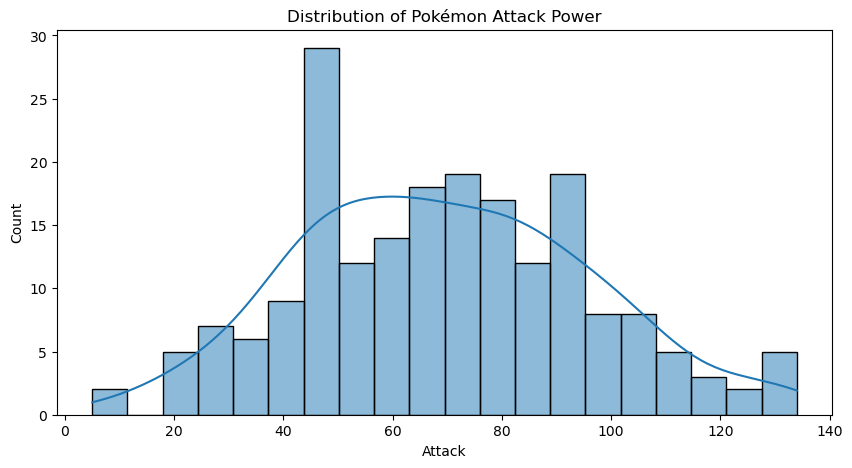

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['attack'],
    bins=20,
    kde=True
)

plt.title("Distribution of Pokémon Attack Power")
plt.xlabel("Attack")
plt.ylabel("Count")

plt.savefig(
    "visualise/attack_distribution.png",
    bbox_inches='tight'
)

plt.show()

C:\Users\vansh\AppData\Local\Temp\ipykernel_2684\3058245123.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_encoded.corr(),


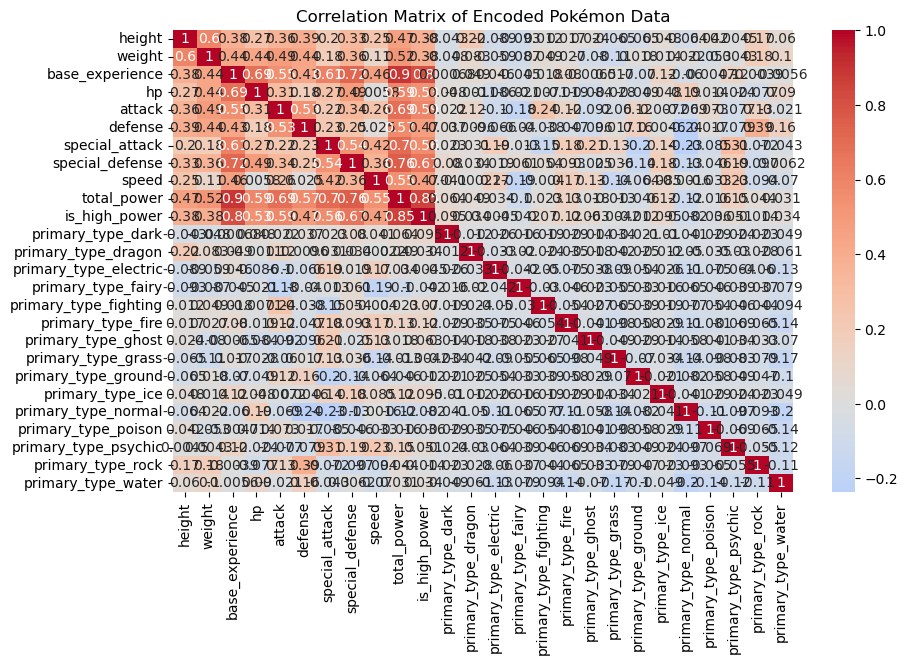

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap='coolwarm',
    center=0
)
plt.title("Correlation Matrix of Encoded Pokémon Data")
plt.savefig(
    "visualise/correlation_matrix.png",
    bbox_inches='tight'
)
plt.show()

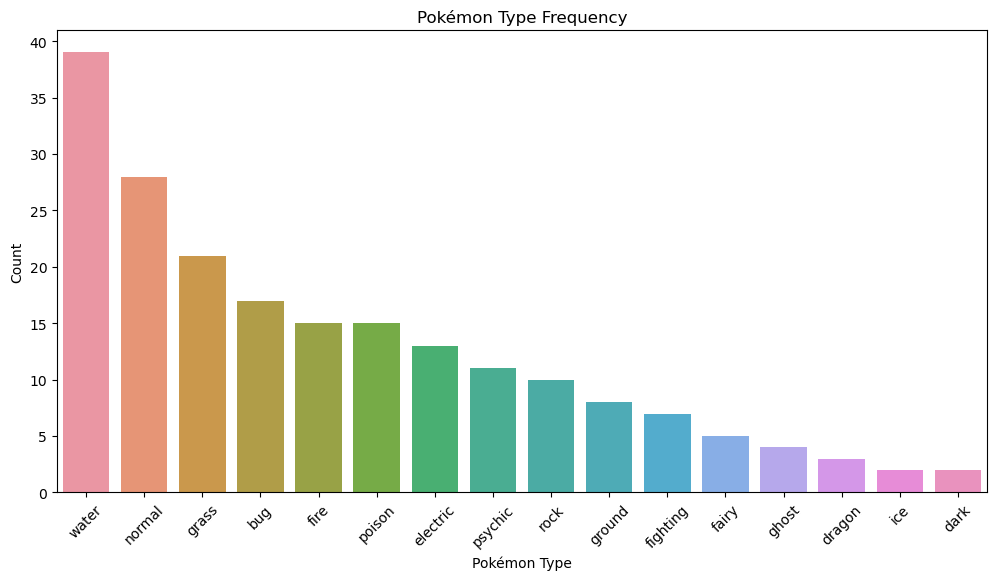

In [30]:
plt.figure(figsize=(12,6))

type_counts = df['primary_type'].value_counts()

sns.barplot(
    x=type_counts.index,
    y=type_counts.values
)

plt.title("Pokémon Type Frequency")
plt.xlabel("Pokémon Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.savefig(
    "visualise/type_frequency_chart.png",
    bbox_inches='tight'
)

plt.show()

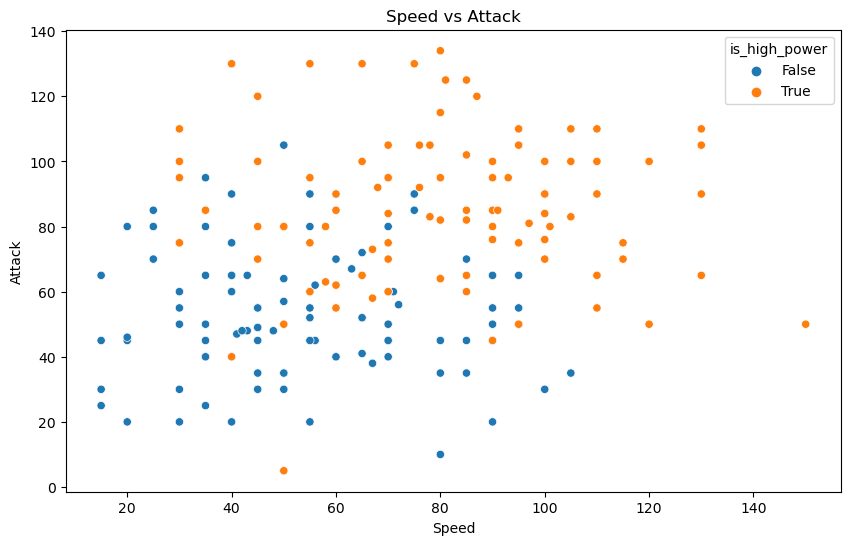

In [31]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='speed',
    y='attack',
    hue='is_high_power',
    data=df
)

plt.title("Speed vs Attack")
plt.xlabel("Speed")
plt.ylabel("Attack")

plt.savefig(
    "visualise/speed_vs_attack.png",
    bbox_inches='tight'
)

plt.show()

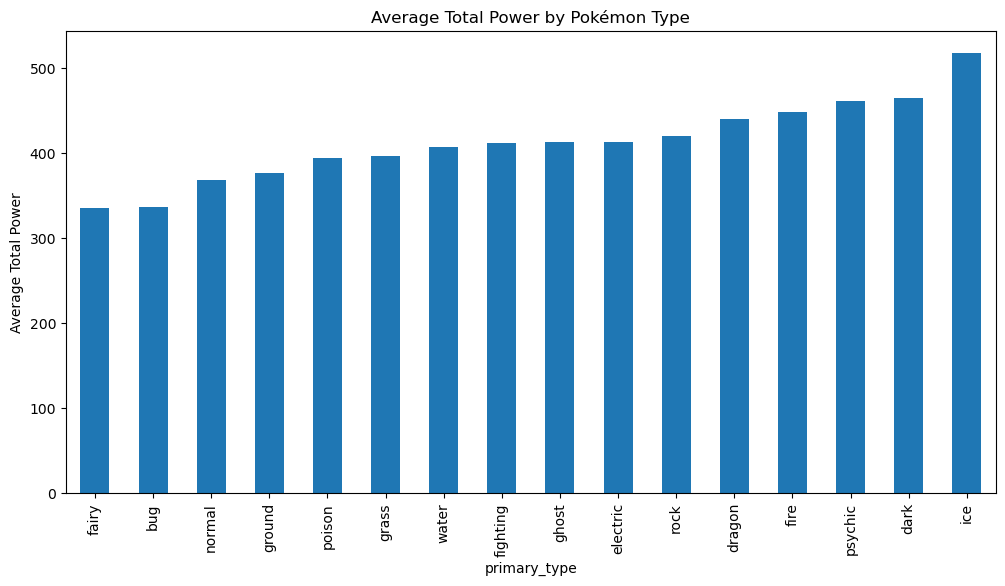

In [33]:
plt.figure(figsize=(12,6))

avg_power = df.groupby('primary_type')['total_power'].mean()

avg_power.sort_values().plot(kind='bar')

plt.title("Average Total Power by Pokémon Type")
plt.ylabel("Average Total Power")

plt.savefig(
    "visualise/type_based_performance.png",
    bbox_inches='tight'
)

plt.show()